# 프로젝트 : 챗봇 만들기

## Step 0. Mecab 설치

In [3]:
%%capture
# Colab에서 mecab 설치 (최초 1회만 실행)
!pip install -qq konlpy
!pip install -qq mecab-python3
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install nltk
!pip install gensim
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.8 MB/s eta 0:00:00
2.0.2
2.2.2
2.11.0+cu128
3.9.1
4.4.0


In [6]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU만 사용")

True
Tesla T4


## Step 1. 데이터 다운로드

In [18]:
import pandas as pd

# 심볼릭 링크로 ChatbotData.csv가 준비되어 있다고 가정
data = pd.read_csv('/content/drive/MyDrive/ChatbotData.csv')

questions = data['Q'].tolist()
answers = data['A'].tolist()

print(f"질문 개수: {len(questions)}, 답변 개수: {len(answers)}")
print(questions[:3])
print(answers[:3])

질문 개수: 11823, 답변 개수: 11823
['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


## Step 2. 데이터 정제

In [19]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    # 한글, 영문, 숫자, 주요 특수문자(. , ! ?)를 제외한 나머지 제거
    sentence = re.sub(r"[^0-9a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣.,!?]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# 테스트
print(preprocess_sentence("아 진짜?? ㅋㅋㅋ 12시 땡!!!"))

아 진짜?? ㅋㅋㅋ 12시 땡!!!


## Step 3. 데이터 토큰화

In [35]:
from konlpy.tag import Mecab

mecab = Mecab()

def build_corpus(src_data, tgt_data, tokenize_fn, max_len=25):
    src_corpus, tgt_corpus = [], []
    src_seen, tgt_seen = set(), set()

    for src_sent, tgt_sent in zip(src_data, tgt_data):
        src_clean = preprocess_sentence(src_sent)
        tgt_clean = preprocess_sentence(tgt_sent)

        src_tokens = tokenize_fn(src_clean)
        tgt_tokens = tokenize_fn(tgt_clean)

        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue

        src_key = " ".join(src_tokens)
        tgt_key = " ".join(tgt_tokens)

        # 소스는 소스대로, 타겟은 타겟대로 중복 검사 (쌍은 함께 유지)
        if src_key in src_seen or tgt_key in tgt_seen:
            continue

        src_seen.add(src_key)
        tgt_seen.add(tgt_key)
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus

que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=25)

print(len(que_corpus), len(ans_corpus))
print(que_corpus[:2])
print(ans_corpus[:2])

7654 7654
[['12', '시', '땡', '!'], ['1', '지망', '학교', '떨어졌', '어']]
[['하루', '가', '또', '가', '네요', '.'], ['위로', '해', '드립니다', '.']]


## Step 4. 데이터 증강(Lexical Substitution)

In [21]:
# Facebook fastText의 한국어 사전학습 벡터
import urllib.request

url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ko.300.vec.gz"
urllib.request.urlretrieve(url, "cc.ko.300.vec.gz")

('cc.ko.300.vec.gz', <http.client.HTTPMessage at 0x7a5d34e82f60>)

In [22]:
import gensim
from gensim.models import KeyedVectors

# .gz 상태로도 gensim이 바로 읽을 수 있습니다 (압축 해제 불필요)
vectors = KeyedVectors.load_word2vec_format("cc.ko.300.vec.gz", binary=False, limit=50000)
# limit: 상위 20만 단어만 로드 (전체 로드시 메모리 많이 사용, 시간도 오래 걸림)

In [23]:
import random

similar_cache = {}

def get_similar(word, vectors, topn=5):
    if word in similar_cache:
        return similar_cache[word]
    try:
        result = [w for w, _ in vectors.most_similar(word, topn=topn)]
    except KeyError:
        result = []
    similar_cache[word] = result
    return result

def lexical_sub(tokens, vectors, topn=5, prob=0.3):
    new_tokens = tokens.copy()
    for i, token in enumerate(tokens):
        if random.random() < prob:
            candidates = get_similar(token, vectors, topn)
            if candidates:
                new_tokens[i] = random.choice(candidates)
    return new_tokens

def augment_corpus(corpus, vectors):
    return [lexical_sub(tokens, vectors) for tokens in corpus]

que_aug1 = augment_corpus(que_corpus, vectors)
ans_aug1 = ans_corpus
que_aug2 = que_corpus
ans_aug2 = augment_corpus(ans_corpus, vectors)

que_corpus = que_corpus + que_aug1 + que_aug2
ans_corpus = ans_corpus + ans_aug1 + ans_aug2

print(f"전체 데이터 개수: {len(que_corpus)}")


전체 데이터 개수: 23049


In [24]:
# 중복 제거 효과만 따로 확인
unique_questions = set(preprocess_sentence(q) for q in questions)
unique_answers = set(preprocess_sentence(a) for a in answers)
print(f"원본 질문: {len(questions)}, 중복 제거 후 고유 질문: {len(unique_questions)}")
print(f"원본 답변: {len(answers)}, 중복 제거 후 고유 답변: {len(unique_answers)}")

원본 질문: 11823, 중복 제거 후 고유 질문: 11661
원본 답변: 11823, 중복 제거 후 고유 답변: 7779


## Step 5. 데이터 벡터화

In [25]:
import numpy as np
import torch
from collections import Counter

# <start>, <end> 토큰 추가
ans_corpus = [["<start>"] + tokens + ["<end>"] for tokens in ans_corpus]

# 소스+타겟 통합 단어 사전 구축 (같은 언어이므로 임베딩 공유 목적)
def build_vocab(corpus_list, min_freq=1):
    counter = Counter()
    for corpus in corpus_list:
        for tokens in corpus:
            counter.update(tokens)
    vocab = ['<pad>', '<unk>', '<start>', '<end>']
    vocab += [w for w, f in counter.items() if f >= min_freq and w not in vocab]
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word

word2idx, idx2word = build_vocab([que_corpus, ans_corpus])
vocab_size = len(word2idx)
PAD_IDX = word2idx['<pad>']

def vectorize(corpus, word2idx):
    return [[word2idx.get(t, word2idx['<unk>']) for t in tokens] for tokens in corpus]

enc_ids = vectorize(que_corpus, word2idx)
dec_ids = vectorize(ans_corpus, word2idx)

max_len_enc = max(len(s) for s in enc_ids)
max_len_dec = max(len(s) for s in dec_ids)

def pad_sequences(sequences, max_len, pad_value):
    arr = np.full((len(sequences), max_len), pad_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        length = min(len(seq), max_len)
        arr[i, :length] = seq[:length]
    return arr

enc_train = pad_sequences(enc_ids, max_len_enc, PAD_IDX)
dec_train = pad_sequences(dec_ids, max_len_dec, PAD_IDX)

print(f"Vocab size: {vocab_size}")
print(f"enc_train: {enc_train.shape}, dec_train: {dec_train.shape}")

Vocab size: 9019
enc_train: (23049, 32), dec_train: (23049, 42)


## Step 6. 훈련하기 (Transformer)

In [26]:
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        b = q.size(0)
        Q = self.w_q(q).view(b, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(b, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(b, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, V).transpose(1, 2).contiguous().view(b, -1, self.n_heads * self.d_k)
        return self.w_o(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Pre-LN: 정규화 먼저 → sub-layer 계산 → residual 더하기
        normed = self.norm1(x)
        x = x + self.drop(self.attn(normed, normed, normed, mask))
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, tgt_mask):
        # Pre-LN: self-attention
        normed = self.norm1(x)
        x = x + self.drop(self.self_attn(normed, normed, normed, tgt_mask))
        # Pre-LN: cross-attention (인코더 출력과 결합)
        normed = self.norm2(x)
        x = x + self.drop(self.cross_attn(normed, enc_out, enc_out, src_mask))
        # Pre-LN: FFN
        x = x + self.drop(self.ffn(self.norm3(x)))
        return x


class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout, max_len, pad_idx):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)  # 공유 임베딩
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.drop = nn.Dropout(dropout)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

        # Pre-LN 구조에서는 스택이 끝난 후 최종 정규화가 필요함
        self.enc_final_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.dec_final_norm = nn.LayerNorm(d_model, eps=1e-6)

        self.fc_out = nn.Linear(d_model, vocab_size)

    def make_src_mask(self, src):
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)
        L = tgt.size(1)
        sub_mask = torch.tril(torch.ones((L, L), device=tgt.device)).bool()
        return pad_mask & sub_mask

    def encode(self, src, src_mask):
        x = self.drop(self.pos_enc(self.embedding(src) * math.sqrt(self.d_model)))
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        x = self.enc_final_norm(x)   # ← 스택 끝나고 최종 정규화
        return x

    def decode(self, tgt, enc_out, src_mask, tgt_mask):
        x = self.drop(self.pos_enc(self.embedding(tgt) * math.sqrt(self.d_model)))
        for layer in self.dec_layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        x = self.dec_final_norm(x)   # ← 스택 끝나고 최종 정규화
        return self.fc_out(x)

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encode(src, src_mask)
        return self.decode(tgt, enc_out, src_mask, tgt_mask)

### 훈련 루프 (과적합 방지용 소규모 하이퍼파라미터):

In [27]:
from torch.utils.data import Dataset, DataLoader

class ChatbotDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc, self.dec = enc, dec
    def __len__(self):
        return len(self.enc)
    def __getitem__(self, idx):
        return torch.tensor(self.enc[idx]), torch.tensor(self.dec[idx])

dataset = ChatbotDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

D_MODEL = 256
model = Transformer(
    vocab_size=vocab_size, d_model=D_MODEL, n_heads=8, n_layers=1,
    d_ff=1024, dropout=0.3, max_len=max(max_len_enc, max_len_dec) + 10, pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

WARMUP_STEPS = 1000
def get_lr(step, d_model, warmup):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)

step_count = 0
N_EPOCHS = 10

model.train()
for epoch in range(N_EPOCHS):
    total_loss = 0
    for enc_batch, dec_batch in dataloader:
        step_count += 1
        lr = get_lr(step_count, D_MODEL, WARMUP_STEPS)
        for g in optimizer.param_groups:
            g['lr'] = lr

        enc_batch, dec_batch = enc_batch.to(device), dec_batch.to(device)
        dec_input, dec_target = dec_batch[:, :-1], dec_batch[:, 1:]

        optimizer.zero_grad()
        output = model(enc_batch, dec_input)
        loss = criterion(output.reshape(-1, vocab_size), dec_target.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{N_EPOCHS}, Loss: {total_loss/len(dataloader):.4f}")

Epoch 1/10, Loss: 6.1540
Epoch 2/10, Loss: 4.0332
Epoch 3/10, Loss: 3.5920
Epoch 4/10, Loss: 3.3010
Epoch 5/10, Loss: 3.0968
Epoch 6/10, Loss: 2.9382
Epoch 7/10, Loss: 2.8092
Epoch 8/10, Loss: 2.6919
Epoch 9/10, Loss: 2.5891
Epoch 10/10, Loss: 2.4866


### 예문에 대한 답변 생성:

In [28]:
def translate(sentence, model, word2idx, idx2word, tokenizer, max_len = 25, repetition_penalty=1.5):
    model.eval()
    tokens = tokenizer(preprocess_sentence(sentence))
    ids = [word2idx.get(t, word2idx['<unk>']) for t in tokens]
    src = torch.tensor([ids], device=device)
    src_mask = model.make_src_mask(src)

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)

    dec_input = torch.tensor([[word2idx['<start>']]], device=device)
    generated_ids = []

    for _ in range(max_len):
        tgt_mask = model.make_tgt_mask(dec_input)
        with torch.no_grad():
            out = model.decode(dec_input, enc_out, src_mask, tgt_mask)

        logits = out[:, -1, :].clone()

        # 이미 나온 단어들의 확률을 낮춰서 반복을 억제
        for prev_id in set(generated_ids):
            logits[0, prev_id] /= repetition_penalty

        next_id = logits.argmax(dim=-1).item()
        generated_ids.append(next_id)
        dec_input = torch.cat([dec_input, torch.tensor([[next_id]], device=device)], dim=1)

        if next_id == word2idx['<end>']:
            break

    return " ".join(idx2word[i] for i in generated_ids[:-1] if idx2word[i] != '<end>')

examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

for ex in examples:
    print(f"입력: {ex}")
    print(f"출력: {translate(ex, model, word2idx, idx2word, mecab.morphs)}\n")

입력: 지루하다, 놀러가고 싶어.
출력: 여행 은 뭐 든 열심히 하 지 마세요 .

입력: 오늘 일찍 일어났더니 피곤하다.
출력: 내일 은 하루 도 좋 을 거 예요 .

입력: 간만에 여자친구랑 데이트 하기로 했어.
출력: 같이 놀 아요 .

입력: 집에 있는다는 소리야.
출력: 집 에서 벗어나 세요 .



## Step 7. 성능 측정 (BLEU Score)

In [29]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

def calculate_bleu(model, que_corpus, ans_corpus, word2idx, idx2word, tokenizer, n_samples=100):
    smoothie = SmoothingFunction().method4
    scores = []
    idxs = random.sample(range(len(que_corpus)), min(n_samples, len(que_corpus)))

    for i in idxs:
        src_sentence = " ".join(que_corpus[i])
        reference = ans_corpus[i][1:-1]  # <start>, <end> 제외
        hypothesis = translate(src_sentence, model, word2idx, idx2word, tokenizer).split()
        if hypothesis and hypothesis[-1] == '<end>':
            hypothesis = hypothesis[:-1]
        scores.append(sentence_bleu([reference], hypothesis, smoothing_function=smoothie))

    return sum(scores) / len(scores)

bleu_score = calculate_bleu(model, que_corpus, ans_corpus, word2idx, idx2word, mecab.morphs)
print(f"평균 BLEU Score: {bleu_score:.4f}")

평균 BLEU Score: 0.0497


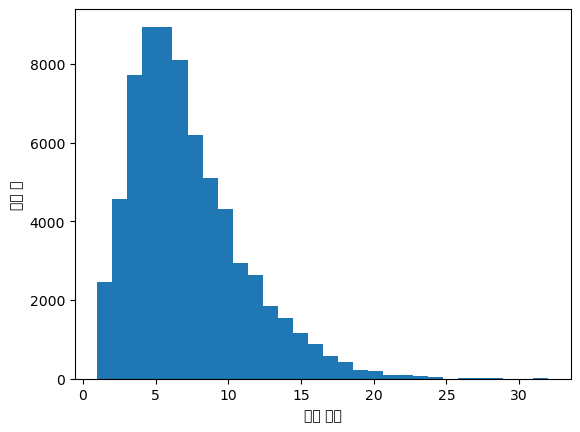

평균: 7.5
최대: 32
90th percentile: 13


In [ ]:
import matplotlib.pyplot as plt

lengths = [len(t) for t in que_corpus]  # 각 문장의 토큰 개수 리스트
plt.hist(lengths, bins=30)
plt.xlabel("토큰 개수")
plt.ylabel("문장 수")
plt.show()

print(f"평균: {sum(lengths)/len(lengths):.1f}")
print(f"최대: {max(lengths)}")
print(f"90th percentile: {sorted(lengths)[int(len(lengths)*0.9)]}")

max_len=25로 설정, dropout = 0.3, d_model 256으로 수정 후 다시 훈련

![](1.png)

![](7.png)

# 회고

원본 11,823개 쌍에 전처리를 적용한 결과, 질문은 11,661개(약 1.4% 감소)로 큰 변화가 없었으나 답변은 7,779개(약 34% 감소)로 크게 줄었다. 이는 챗봇 데이터 특성상 "저도요", "감사합니다" 등 범용 답변이 여러 질문에 반복적으로 사용되기 때문으로 분석된다. max_len=25 필터링으로는 5개 문장만 추가로 제외되어 영향은 미미했다. 최종적으로 질문/답변 쌍 기준 7,654개의 고유 데이터를 확보했으며, Lexical Substitution 기반 augmentation(3배)을 적용해 22,962개의 훈련 데이터셋을 구축하였다.beam search, train/val split, 등 여러가지 방법을 적용 해보았는데 beam width=5일 때 가장 성능이 높았다.  
BLEU 단독 지표의 함정: 챗봇처럼 정답이 여러 개 가능한 open-ended 태스크에서는 BLEU가 실제 답변 품질과 반비례하는 경우가 반복적으로 관찰됨. 정성 평가(예문 출력)를 병행해야 함.  
훈련 데이터 기준 BLEU의 착시: 훈련 데이터로 측정한 BLEU는 암기 여부를 구분하지 못해 부풀려질 수 있음. Validation 분리 후에야 진짜 일반화 성능을 확인할 수 있었음.  
decoding 전략과 모델 학습은 별개 문제: repetition penalty, beam search는 재훈련 없이 즉시 적용/비교 가능했고, 실제로 반복 루프 문제의 상당 부분을 이 단계에서 해결함.  
작은 데이터셋에서의 과적합은 빠르게 온다: 23,000개 규모, 1-layer 모델에서도 단 2~3 epoch 만에 과적합이 시작되는 것을 loss curve로 직접 확인.




![](./12.png)

beam search를 통해 챗봇 성능을 높여보자.

In [30]:
import torch

def translate_beam(sentence, model, word2idx, idx2word, tokenizer, max_len=25, beam_width=3, length_penalty=0.7):
    model.eval()
    tokens = tokenizer(preprocess_sentence(sentence))
    ids = [word2idx.get(t, word2idx['<unk>']) for t in tokens]
    src = torch.tensor([ids], device=device)
    src_mask = model.make_src_mask(src)

    with torch.no_grad():
        enc_out = model.encode(src, src_mask)

    end_id = word2idx['<end>']
    start_id = word2idx['<start>']

    # (누적 log-prob, 토큰 시퀀스, 종료 여부)
    beams = [(0.0, [start_id], False)]
    completed = []

    for _ in range(max_len):
        candidates = []

        for score, seq, done in beams:
            if done:
                completed.append((score, seq))
                continue

            dec_input = torch.tensor([seq], device=device)
            tgt_mask = model.make_tgt_mask(dec_input)
            with torch.no_grad():
                out = model.decode(dec_input, enc_out, src_mask, tgt_mask)
            log_probs = torch.log_softmax(out[:, -1, :], dim=-1)
            topk = torch.topk(log_probs, beam_width, dim=-1)

            for i in range(beam_width):
                next_id = topk.indices[0, i].item()
                next_score = score + topk.values[0, i].item()
                is_end = (next_id == end_id)
                candidates.append((next_score, seq + [next_id], is_end))

        if not candidates:
            break

        # length_penalty 적용해서 정렬 (짧은 문장에 유리해지는 편향 보정)
        def norm_score(c):
            s, seq, _ = c
            length = len(seq)
            return s / (length ** length_penalty)

        candidates.sort(key=norm_score, reverse=True)
        beams = candidates[:beam_width]

        if len(completed) >= beam_width:
            break

    completed += [(s, seq) for s, seq, done in beams]
    completed.sort(key=lambda c: c[0] / (len(c[1]) ** length_penalty), reverse=True)

    best_seq = completed[0][1]
    result_tokens = [idx2word[i] for i in best_seq[1:] if idx2word[i] not in ['<end>', '<start>']]
    return " ".join(result_tokens)

In [31]:
examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("=== Greedy (repetition penalty) 결과 ===")
for ex in examples:
    print(f"입력: {ex}")
    print(f"출력: {translate(ex, model, word2idx, idx2word, mecab.morphs)}\n")

print("=== Beam Search (width=3) 결과 ===")
for ex in examples:
    print(f"입력: {ex}")
    print(f"출력: {translate_beam(ex, model, word2idx, idx2word, mecab.morphs, beam_width=3)}\n")

=== Greedy (repetition penalty) 결과 ===
입력: 지루하다, 놀러가고 싶어.
출력: 여행 은 뭐 든 열심히 하 지 마세요 .

입력: 오늘 일찍 일어났더니 피곤하다.
출력: 내일 은 하루 도 좋 을 거 예요 .

입력: 간만에 여자친구랑 데이트 하기로 했어.
출력: 같이 놀 아요 .

입력: 집에 있는다는 소리야.
출력: 집 에서 벗어나 세요 .

=== Beam Search (width=3) 결과 ===
입력: 지루하다, 놀러가고 싶어.
출력: 잠깐 쉬 는 게 좋 죠 .

입력: 오늘 일찍 일어났더니 피곤하다.
출력: 언젠간 닥쳐올 순간 이 에요 .

입력: 간만에 여자친구랑 데이트 하기로 했어.
출력: 이성 으로 다가가 보 세요 .

입력: 집에 있는다는 소리야.
출력: 집 에서 벗어나 세요 .



In [33]:
for bw in [2, 3, 5]:
    print(f"\n--- beam_width={bw} ---")
    for ex in examples:
        result = translate_beam(ex, model, word2idx, idx2word, mecab.morphs, beam_width=bw)
        print(f"입력: {ex} → 출력: {result}")


--- beam_width=2 ---
입력: 지루하다, 놀러가고 싶어. → 출력: 잠깐 쉬 는 게 좋 죠 .
입력: 오늘 일찍 일어났더니 피곤하다. → 출력: 언젠간 닥쳐올 순간 이 에요 .
입력: 간만에 여자친구랑 데이트 하기로 했어. → 출력: 이성 으로 다가가 보 세요 .
입력: 집에 있는다는 소리야. → 출력: 집 에서 벗어나 세요 .

--- beam_width=3 ---
입력: 지루하다, 놀러가고 싶어. → 출력: 잠깐 쉬 는 게 좋 죠 .
입력: 오늘 일찍 일어났더니 피곤하다. → 출력: 언젠간 닥쳐올 순간 이 에요 .
입력: 간만에 여자친구랑 데이트 하기로 했어. → 출력: 이성 으로 다가가 보 세요 .
입력: 집에 있는다는 소리야. → 출력: 집 에서 벗어나 세요 .

--- beam_width=5 ---
입력: 지루하다, 놀러가고 싶어. → 출력: 잠깐 쉬 는 게 좋 죠 .
입력: 오늘 일찍 일어났더니 피곤하다. → 출력: 언젠간 닥쳐올 순간 이 에요 .
입력: 간만에 여자친구랑 데이트 하기로 했어. → 출력: 합리 적 인 소비 를 해 보 세요 .
입력: 집에 있는다는 소리야. → 출력: 집 에서 벗어나 세요 .


In [34]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

def calculate_bleu_beam(model, que_corpus, ans_corpus, word2idx, idx2word, tokenizer, n_samples=100, beam_width=3):
    smoothie = SmoothingFunction().method4
    scores = []
    idxs = random.sample(range(len(que_corpus)), min(n_samples, len(que_corpus)))

    for i in idxs:
        src_sentence = " ".join(que_corpus[i])
        reference = ans_corpus[i][1:-1]  # <start>, <end> 제외
        hypothesis = translate_beam(src_sentence, model, word2idx, idx2word, tokenizer, beam_width=beam_width).split()
        scores.append(sentence_bleu([reference], hypothesis, smoothing_function=smoothie))

    return sum(scores) / len(scores)

bleu_beam = calculate_bleu_beam(model, que_corpus, ans_corpus, word2idx, idx2word, mecab.morphs, beam_width=3)
print(f"Beam Search(width=3) 평균 BLEU: {bleu_beam:.4f}")

Beam Search(width=3) 평균 BLEU: 0.0812


훈련, 검증용 데이터를 나눠서 재훈련 해보자.

1. Step 3 직후 데이터로 Train/Validation 분리

In [36]:
from sklearn.model_selection import train_test_split

# Step 3에서 만든 원본 (augmentation 전) que_corpus, ans_corpus를 사용
# 만약 이미 augmentation된 상태로 덮어쓰셨다면, Step 3 build_corpus()를 다시 실행해서 원본부터 확보하세요
que_corpus_raw, ans_corpus_raw = build_corpus(questions, answers, mecab.morphs, max_len=25)

que_train_raw, que_val_raw, ans_train_raw, ans_val_raw = train_test_split(
    que_corpus_raw, ans_corpus_raw, test_size=0.1, random_state=42
)

print(f"Train (원본): {len(que_train_raw)}, Validation (원본): {len(que_val_raw)}")

Train (원본): 6888, Validation (원본): 766


2. Train 데이터만 Augmentation (Validation은 원본 그대로 유지)

In [37]:
similar_cache = {}

def get_similar(word, vectors, topn=5):
    if word in similar_cache:
        return similar_cache[word]
    try:
        result = [w for w, _ in vectors.most_similar(word, topn=topn)]
    except KeyError:
        result = []
    similar_cache[word] = result
    return result

def lexical_sub(tokens, vectors, topn=5, prob=0.3):
    new_tokens = tokens.copy()
    for i, token in enumerate(tokens):
        if random.random() < prob:
            candidates = get_similar(token, vectors, topn)
            if candidates:
                new_tokens[i] = random.choice(candidates)
    return new_tokens

def augment_corpus(corpus, vectors):
    return [lexical_sub(tokens, vectors) for tokens in corpus]

# Train만 augmentation
que_aug1 = augment_corpus(que_train_raw, vectors)
ans_aug1 = ans_train_raw
que_aug2 = que_train_raw
ans_aug2 = augment_corpus(ans_train_raw, vectors)

que_train = que_train_raw + que_aug1 + que_aug2
ans_train = ans_train_raw + ans_aug1 + ans_aug2

# Validation은 augmentation 없이 원본 그대로
que_val = que_val_raw
ans_val = ans_val_raw

print(f"최종 Train: {len(que_train)}, Validation: {len(que_val)}")

최종 Train: 20664, Validation: 766


3. <start>/<end> 추가 및 벡터화 (Train/Val 각각)

In [38]:
ans_train = [["<start>"] + tokens + ["<end>"] for tokens in ans_train]
ans_val = [["<start>"] + tokens + ["<end>"] for tokens in ans_val]

# 단어 사전은 train 기준으로만 구축 (validation의 새 단어는 <unk> 처리되는 게 맞음 - 실제 일반화 테스트 취지에 부합)
word2idx, idx2word = build_vocab([que_train, ans_train])
vocab_size = len(word2idx)
PAD_IDX = word2idx['<pad>']

def vectorize(corpus, word2idx):
    return [[word2idx.get(t, word2idx['<unk>']) for t in tokens] for tokens in corpus]

enc_train_ids = vectorize(que_train, word2idx)
dec_train_ids = vectorize(ans_train, word2idx)
enc_val_ids = vectorize(que_val, word2idx)
dec_val_ids = vectorize(ans_val, word2idx)

max_len_enc = max(len(s) for s in enc_train_ids)
max_len_dec = max(len(s) for s in dec_train_ids)

def pad_sequences(sequences, max_len, pad_value):
    arr = np.full((len(sequences), max_len), pad_value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        length = min(len(seq), max_len)
        arr[i, :length] = seq[:length]
    return arr

enc_train_arr = pad_sequences(enc_train_ids, max_len_enc, PAD_IDX)
dec_train_arr = pad_sequences(dec_train_ids, max_len_dec, PAD_IDX)
enc_val_arr = pad_sequences(enc_val_ids, max_len_enc, PAD_IDX)   # train 기준 max_len 사용
dec_val_arr = pad_sequences(dec_val_ids, max_len_dec, PAD_IDX)

print(f"Train: enc {enc_train_arr.shape}, dec {dec_train_arr.shape}")
print(f"Val: enc {enc_val_arr.shape}, dec {dec_val_arr.shape}")

Train: enc (20664, 24), dec (20664, 27)
Val: enc (766, 24), dec (766, 27)


4. DataLoader 준비 (Train/Val 각각)

In [39]:
class ChatbotDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc, self.dec = enc, dec
    def __len__(self):
        return len(self.enc)
    def __getitem__(self, idx):
        return torch.tensor(self.enc[idx]), torch.tensor(self.dec[idx])

train_dataset = ChatbotDataset(enc_train_arr, dec_train_arr)
val_dataset = ChatbotDataset(enc_val_arr, dec_val_arr)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)

5. Label Smoothing 적용 + Validation Loss 함께 기록하는 훈련 루프

In [41]:
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

D_MODEL = 256
max_len_model = max(max_len_enc, max_len_dec) + 10

model = Transformer(   # Step 6의 Pre-LN 클래스
    vocab_size=vocab_size, d_model=D_MODEL, n_heads=8, n_layers=1,
    d_ff=1024, dropout=0.3, max_len=max_len_model, pad_idx=PAD_IDX
).to(device)

# Label smoothing 적용 (핵심 변경 지점)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

WARMUP_STEPS = 1000
def get_lr(step, d_model, warmup):
    step = max(step, 1)
    return (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)

def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for enc_batch, dec_batch in dataloader:
            enc_batch, dec_batch = enc_batch.to(device), dec_batch.to(device)
            dec_input, dec_target = dec_batch[:, :-1], dec_batch[:, 1:]
            output = model(enc_batch, dec_input)
            loss = criterion(output.reshape(-1, vocab_size), dec_target.reshape(-1))
            total_loss += loss.item()
    model.train()
    return total_loss / len(dataloader)

step_count = 0
N_EPOCHS = 10
train_loss_history = []
val_loss_history = []

model.train()
for epoch in range(N_EPOCHS):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}", leave=True)

    for enc_batch, dec_batch in progress_bar:
        step_count += 1
        lr = get_lr(step_count, D_MODEL, WARMUP_STEPS)
        for g in optimizer.param_groups:
            g['lr'] = lr

        enc_batch, dec_batch = enc_batch.to(device), dec_batch.to(device)
        dec_input, dec_target = dec_batch[:, :-1], dec_batch[:, 1:]

        optimizer.zero_grad()
        output = model(enc_batch, dec_input)
        loss = criterion(output.reshape(-1, vocab_size), dec_target.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")

    avg_train_loss = total_loss / len(train_dataloader)
    avg_val_loss = evaluate(model, val_dataloader, criterion)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{N_EPOCHS} — Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1/10: 100%|██████████| 323/323 [00:07<00:00, 43.95it/s, loss=5.2421, lr=6.38e-04]


Epoch 1/10 — Train Loss: 6.7411, Val Loss: 4.9961


Epoch 2/10: 100%|██████████| 323/323 [00:07<00:00, 42.23it/s, loss=4.5648, lr=1.28e-03]


Epoch 2/10 — Train Loss: 4.8424, Val Loss: 4.5905


Epoch 3/10: 100%|██████████| 323/323 [00:09<00:00, 35.33it/s, loss=4.3562, lr=1.92e-03]


...

Epoch 8/10 — Train Loss: 3.6690, Val Loss: 4.5289


Epoch 9/10: 100%|██████████| 323/323 [00:06<00:00, 46.36it/s, loss=3.4031, lr=1.16e-03]


Epoch 9/10 — Train Loss: 3.5791, Val Loss: 4.5854


Epoch 10/10: 100%|██████████| 323/323 [00:06<00:00, 48.13it/s, loss=3.6652, lr=1.10e-03]


Epoch 10/10 — Train Loss: 3.4936, Val Loss: 4.6155


6. Train vs Validation Loss 곡선으로 과적합 여부 직접 확인

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


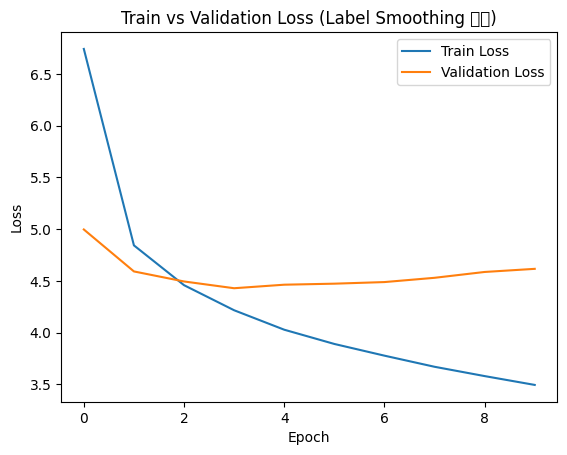

In [42]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Validation Loss (Label Smoothing 적용)")
plt.show()

7. Validation 데이터로 진짜 일반화 성능(BLEU) 측정

In [43]:
bleu_val = calculate_bleu_beam(model, que_val, ans_val, word2idx, idx2word, mecab.morphs, beam_width=3)
print(f"Validation 기준 BLEU (모델이 안 본 데이터): {bleu_val:.4f}")

Validation 기준 BLEU (모델이 안 본 데이터): 0.0379


In [44]:
best_val_loss = float('inf')
best_epoch = -1

model.train()
for epoch in range(N_EPOCHS):
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}", leave=True)

    for enc_batch, dec_batch in progress_bar:
        step_count += 1
        lr = get_lr(step_count, D_MODEL, WARMUP_STEPS)
        for g in optimizer.param_groups:
            g['lr'] = lr

        enc_batch, dec_batch = enc_batch.to(device), dec_batch.to(device)
        dec_input, dec_target = dec_batch[:, :-1], dec_batch[:, 1:]

        optimizer.zero_grad()
        output = model(enc_batch, dec_input)
        loss = criterion(output.reshape(-1, vocab_size), dec_target.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")

    avg_train_loss = total_loss / len(train_dataloader)
    avg_val_loss = evaluate(model, val_dataloader, criterion)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{N_EPOCHS} — Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Val loss가 이전보다 좋아졌으면 체크포인트 저장
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  → 새로운 best model 저장 (epoch {best_epoch}, val_loss {best_val_loss:.4f})")

print(f"\n최종 best epoch: {best_epoch}, val_loss: {best_val_loss:.4f}")

Epoch 1/10: 100%|██████████| 323/323 [00:07<00:00, 45.39it/s, loss=3.5838, lr=1.05e-03]


Epoch 1/10 — Train Loss: 3.4145, Val Loss: 4.6684
  → 새로운 best model 저장 (epoch 1, val_loss 4.6684)


Epoch 2/10: 100%|██████████| 323/323 [00:07<00:00, 45.87it/s, loss=3.4679, lr=1.00e-03]


Epoch 2/10 — Train Loss: 3.3407, Val Loss: 4.6899


Epoch 3/10: 100%|██████████| 323/323 [00:07<00:00, 44.70it/s, loss=3.2847, lr=9.65e-04]


...

Epoch 8/10 — Train Loss: 2.9978, Val Loss: 4.8926


Epoch 9/10: 100%|██████████| 323/323 [00:06<00:00, 47.02it/s, loss=3.0519, lr=7.98e-04]


Epoch 9/10 — Train Loss: 2.9561, Val Loss: 4.9205


Epoch 10/10: 100%|██████████| 323/323 [00:06<00:00, 46.70it/s, loss=2.8738, lr=7.78e-04]


Epoch 10/10 — Train Loss: 2.9123, Val Loss: 4.9475

최종 best epoch: 1, val_loss: 4.6684


In [45]:
best_model = Transformer(
    vocab_size=vocab_size, d_model=D_MODEL, n_heads=8, n_layers=1,
    d_ff=1024, dropout=0.3, max_len=max_len_model, pad_idx=PAD_IDX
).to(device)
best_model.load_state_dict(torch.load("best_model.pt"))
best_model.eval()

# 이 모델로 생성 결과와 BLEU 확인
for ex in examples:
    print(f"입력: {ex} → 출력: {translate_beam(ex, best_model, word2idx, idx2word, mecab.morphs, beam_width=3)}")

bleu_best = calculate_bleu_beam(best_model, que_val, ans_val, word2idx, idx2word, mecab.morphs, beam_width=3)
print(f"Best 모델(epoch {best_epoch}) Validation BLEU: {bleu_best:.4f}")

입력: 지루하다, 놀러가고 싶어. → 출력: 같이 가 보 세요 .
입력: 오늘 일찍 일어났더니 피곤하다. → 출력: 실감 이 복잡 하 겠 어요 .
입력: 간만에 여자친구랑 데이트 하기로 했어. → 출력: 같이 운동 해 보 세요 .
입력: 집에 있는다는 소리야. → 출력: 네 말씀 해 보 세요 .
Best 모델(epoch 1) Validation BLEU: 0.0418
